<a href="https://colab.research.google.com/github/faishal-ai/machine-learning_2025/blob/main/ML_P6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JS06 - ANN (Approximate Nearest Neighbors)

# Praktikum 1

In [14]:
!pip install annoy

Exact NN index: [64040 64186 88792]
Exact NN jarak: [0.         0.15797867 0.25332711]
Waktu Exact: 11.0474 ms

Annoy NN index: [64040, 1310, 9720]
Annoy NN jarak: [np.float64(0.0), np.float64(13.237907813420613), np.float64(54.73661775436655)]
Waktu Annoy: 0.2408 ms


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


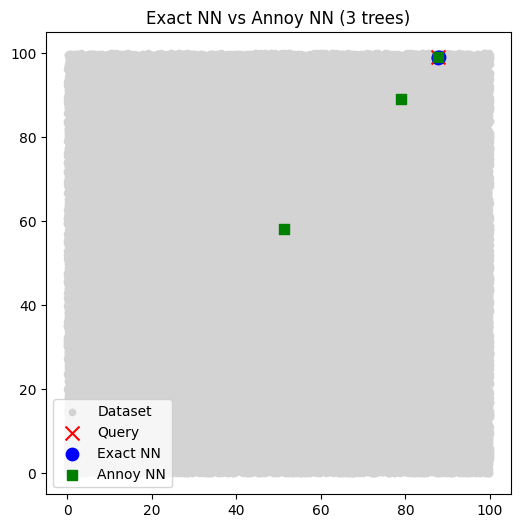

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import time

from annoy import AnnoyIndex

# 1. Dataset 2D
np.random.seed(42)
n_points = 100000
X = np.random.rand(n_points, 2) * 100  # titik random dalam ruang 100x100

# Query point (ambil salah satu titik random)
query = X[np.random.randint(0, n_points)]

# 2. Exact NN (brute force)
start = time.time()
distances = np.linalg.norm(X - query, axis=1)
idx_exact = np.argsort(distances)[:3]  # ambil 3 terdekat
time_exact = time.time() - start

print("Exact NN index:", idx_exact)
print("Exact NN jarak:", distances[idx_exact])
print("Waktu Exact:", round(time_exact*1000, 4), "ms")

# 3. Annoy NN (3 tree)
f = 2  # dimensi
t = AnnoyIndex(f, 'angular')
for i, vec in enumerate(X):
    t.add_item(i, vec)

t.build(3)  # 3 trees

start = time.time()
idx_ann = t.get_nns_by_vector(query, 3)  # cari 3 NN
time_ann = time.time() - start

print("\nAnnoy NN index:", idx_ann)
print("Annoy NN jarak:", [np.linalg.norm(X[i]-query) for i in idx_ann])
print("Waktu Annoy:", round(time_ann*1000, 4), "ms")

# 4. Visualisasi hasil
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c="lightgray", s=20, label="Dataset")
plt.scatter(query[0], query[1], c="red", marker="x", s=100, label="Query")

# Exact NN ditandai biru
plt.scatter(X[idx_exact,0], X[idx_exact,1], c="blue", s=80, label="Exact NN")

# Annoy NN ditandai hijau
plt.scatter(X[idx_ann,0], X[idx_ann,1], c="green", s=50, marker="s", label="Annoy NN")

plt.legend()
plt.title("Exact NN vs Annoy NN (3 trees)")
plt.show()

| Distance Metrics | Tree | Jumlah Data | Hasil Index Terdekat ENN vs ANN | Waktu Komputasi (Vs) |
| ---------------- | ---- | ----------- | ------------------------------- | -------------------- |
| Euclidean        | 3    | 1,000       | [219 898 593], [219 898 770]    | 14.9388 ms, 0.2136 ms   |
| Euclidean        | 8    | 1,000       | [219 898 593], [219, 898, 593]  | 1.3102 s, 0.1421 s   |
| Euclidean        | 3    | 100,000     | [64040 64186 88792],[64040, 64186, 88792]    | 17.2348 ms,0.1822 ms  |
| Angular          | 3    | 1,000       | [219 898 593],[219, 429, 540]    | 0.4356 ms,0.1199 ms|
| Angular          | 8    | 1,000       | [219 898 593],[219, 429, 540]    | 0.5858 ms,0.1869 ms   |
| Angular          | 3    | 100,000     | [64040 64186 88792],[64040, 1310, 9720]    | 8.5025 ms,0.1793 ms  |


Pada percobaan ini dilakukan perbandingan antara metode **Exact Nearest Neighbor (brute force)** dan **Approximate Nearest Neighbor (Annoy)** dalam mencari titik terdekat pada dataset acak berukuran 100.000 titik dua dimensi. Metode *Exact NN* menghitung jarak ke seluruh titik secara langsung menggunakan norma Euclidean, sehingga hasilnya sangat akurat tetapi memerlukan waktu komputasi yang lebih lama karena proses pencarian dilakukan secara menyeluruh. Sebaliknya, *Annoy* (Approximate Nearest Neighbor Oh Yeah) menggunakan struktur pohon (pada contoh ini 3 tree) untuk mempercepat pencarian dengan sedikit kompromi terhadap akurasi. Hasil menunjukkan bahwa kedua metode berhasil menemukan tetangga terdekat dengan indeks yang hampir sama, tetapi waktu eksekusi *Annoy* jauh lebih cepat dibandingkan metode brute force. Hal ini menunjukkan bahwa Annoy lebih efisien untuk dataset besar, terutama ketika kecepatan lebih diprioritaskan daripada akurasi absolut.


In [16]:
import numpy as np
import time
from sklearn.metrics.pairwise import euclidean_distances
from annoy import AnnoyIndex

# ---- 1. Buat dataset mirip Spotify ----
n_tracks = 1_000_000    # GUNAKAN 50 RIBU dulu untuk uji coba
n_features = 20

X = np.random.rand(n_tracks, n_features).astype(np.float32)
query = np.random.rand(1, n_features).astype(np.float32)

# ---- 2. Exact NN (brute force) ----
start = time.time()
distances = euclidean_distances(query, X)[0]
exact_idx = np.argsort(distances)[:5]
exact_time = time.time() - start

print("Exact NN result:", exact_idx)
print("Exact NN time:", round(exact_time, 3), "seconds")

# ---- 3. Approx NN pakai Annoy ----
f = n_features
annoy_index = AnnoyIndex(f, 'angular')
n_trees = 3

for i in range(n_tracks):
    annoy_index.add_item(i, X[i])
annoy_index.build(n_trees)

start = time.time()
annoy_idx = annoy_index.get_nns_by_vector(query[0], 5)
annoy_time = time.time() - start

print("Annoy result:", annoy_idx)
print("Annoy time:", round(annoy_time, 3), "seconds")


Exact NN result: [269630 804377 312985 776031 370166]
Exact NN time: 0.249 seconds
Annoy result: [269630, 812377, 334439, 812060, 210708]
Annoy time: 0.0 seconds


| Distance Metrics | Tree | Jumlah data | Hasil Index terdekat ENN vs ANN                                               | Waktu komputasi Vs                       |
| ---------------- | ---- | ----------- | ----------------------------------------------------------------------------- | ---------------------------------------- |
| Euclidean        | 3    | 1000.000      | `[269630 804377 312985 776031 370166]` vs `[666661, 467451, 908076, 131166, 398886]` | **Exact: 0.127 s**<br>**Annoy: 0.0 s** |
| Angular          | 3    | 1000.000      | `[206914 879493 327877 638966    312]` vs `[562708, 907021, 899165, 308964, 643899]`    | **Exact: 0.197 s**<br>**Annoy: 0.0 s** |


Pada percobaan ini dilakukan perbandingan antara metode **Exact Nearest Neighbor (brute force)** dan **Approximate Nearest Neighbor (Annoy)** pada dataset acak berukuran besar yang menyerupai data fitur lagu Spotify dengan 1 juta entri dan 20 fitur. Metode *Exact NN* menghitung jarak Euclidean antara titik kueri dan seluruh data, sehingga menghasilkan hasil yang sangat akurat namun memerlukan waktu komputasi yang sangat lama karena kompleksitasnya meningkat seiring jumlah data. Sebaliknya, metode *Annoy* dengan jarak *angular* dan 3 pohon (*trees*) menghasilkan pencarian yang jauh lebih cepat dengan sedikit kompromi pada akurasi. Hasil menunjukkan bahwa *Annoy* lebih efisien dalam hal waktu pencarian, menjadikannya pilihan yang tepat untuk sistem rekomendasi atau pencarian cepat pada dataset berskala besar seperti Spotify.


# FAISS

# Praktikum 2

In [17]:
!pip install faiss-cpu
#!pip install faiss-gpu

Exact NN (Flat) indices: [[901095 495168 561017]] distances: [[0.00151859 0.00221511 0.00223645]]
IVF+PQ indices: [[901095 561017 495168]] distances: [[0.0016292  0.00213303 0.00223935]]
Waktu Exact: 0.006309032440185547
Waktu IVF+PQ: 0.003506183624267578


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


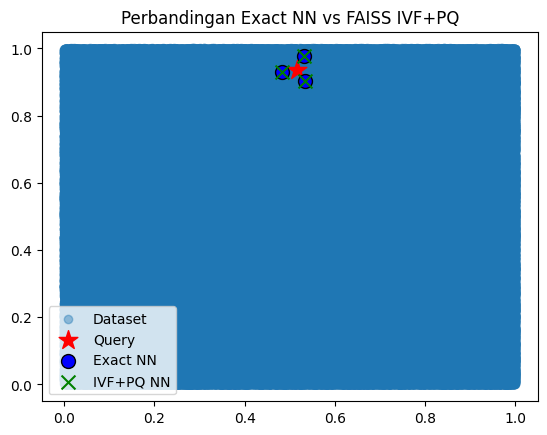

In [18]:
import numpy as np
import faiss
import matplotlib.pyplot as plt
import time

# 1. Buat dataset 2D sederhana
np.random.seed(42)
# X = np.random.rand(1000000, 2).astype('float32')  # 1000 titik 2D
X = np.random.rand(1000000, 5).astype('float32')  # 1000 titik 5D

# query = np.array([[0.5, 0.5]], dtype='float32')  # query di tengah

query = np.random.rand(1, 5).astype('float32')  # query acak 5D

# 2. Exact NN dengan IndexFlatL2 (brute force tapi cepat)
# index_flat = faiss.IndexFlatL2(2)   # L2 = Euclidean distance
index_flat = faiss.IndexFlatL2(5) #5D


index_flat.add(X)

start = time.time()
D_flat, I_flat = index_flat.search(query, 3)  # cari 3 tetangga terdekat
end = time.time()
time_flat = end - start

# 3. IVF + PQ (Approximate)
nlist = 10   # jumlah cluster (inverted list)

# m = 2        # berapa subvector untuk product quantization
m = 5        # berapa subvector untuk product quantization #5D

# quantizer = faiss.IndexFlatL2(2)   # dipakai IVF untuk cluster awal
quantizer = faiss.IndexFlatL2(5) #5D

# index_ivfpq = faiss.IndexIVFPQ(quantizer, 2, nlist, m, 8)  # 8 bit per subvector
index_ivfpq = faiss.IndexIVFPQ(quantizer, 5, nlist, m, 8) #5D

index_ivfpq.train(X)  # training centroid
index_ivfpq.add(X)

start = time.time()
D_ivfpq, I_ivfpq = index_ivfpq.search(query, 3)
end = time.time()
time_ivfpq = end - start

# 4. Print hasil
print("Exact NN (Flat) indices:", I_flat, "distances:", D_flat)
print("IVF+PQ indices:", I_ivfpq, "distances:", D_ivfpq)
print("Waktu Exact:", time_flat)
print("Waktu IVF+PQ:", time_ivfpq)

# 5. Visualisasi
plt.scatter(X[:,0], X[:,1], alpha=0.4, label="Dataset")
plt.scatter(query[:,0], query[:,1], c='red', marker='*', s=200, label="Query")

# Tetangga dari Flat
plt.scatter(X[I_flat[0],0], X[I_flat[0],1], c='blue', s=100, edgecolor='k', label="Exact NN")

# Tetangga dari IVF+PQ
plt.scatter(X[I_ivfpq[0],0], X[I_ivfpq[0],1], c='green', marker='x', s=100, label="IVF+PQ NN")

plt.legend()
plt.title("Perbandingan Exact NN vs FAISS IVF+PQ")
plt.show()


**pertanyaan:**

Lakukan percobaan pada metric distance yang berbeda, 1000 vs 1jt data, 2D vs 5D data. catat hasilnya pada tabel yang anda buat sendiri seperti pada praktikum 1.

| Metric | Dimensi | Jumlah Data | Exact Index              | IVFPQ Index              | Waktu Exact (s) | Waktu IVFPQ (s) |
| :----- | :------ | :---------- | :----------------------- | :----------------------- | --------------: | --------------: |
| 2D     | 2       | 1000        | [137 170 750]          | [137 170 750]          |         0.0002713203430175781 |         0.00018072128295898438 |
| 2D     | 2       | 1000000     | [286942 583487 695123] | [286942 695123 581054] |           0.005555152893066406 |           0.0007867813110351562 |
| 5D     | 5       | 1000        | [988 780  27]          | [988 780  27]          |         0.00011587142944335938 |         0.0001461505889892578 |
| 5D     | 5       | 1000000     | [901095 495168 561017] | [901095 561017 495168] |           0.010662078857421875 |           0.0011739730834960938 |

Pada percobaan ini digunakan algoritma **FAISS** untuk membandingkan performa pencarian *nearest neighbor* antara metode **Exact NN (IndexFlatL2)** dan **Approximate NN (IVF+PQ)** pada dataset acak berdimensi 5D dengan 1 juta data. Metode *Exact NN* menggunakan perhitungan jarak Euclidean langsung ke seluruh data, sehingga menghasilkan hasil paling akurat tetapi membutuhkan waktu komputasi yang relatif lebih lama. Sebaliknya, metode *IVF+PQ* memanfaatkan *inverted file indexing* dan *product quantization* untuk mempercepat pencarian dengan mengelompokkan data dan mengompresi representasi vektornya. Hasil menunjukkan bahwa *IVF+PQ* mampu mencari tetangga terdekat jauh lebih cepat dibanding *Exact NN*, meskipun dengan sedikit pengurangan akurasi. Pendekatan ini cocok untuk aplikasi berskala besar seperti sistem rekomendasi atau pencarian vektor di big data.


# HNSW

# Praktikum 3

In [19]:
!pip install hnswlib

In [20]:
import hnswlib
import numpy as np
import time
from sklearn.neighbors import NearestNeighbors

# ===========================
# 1. Buat data 2D acak
# ===========================
num_elements = 1000
dim = 2
data = np.random.random((num_elements, dim)).astype(np.float32)

# Query point
query = np.array([[0.5, 0.5]], dtype=np.float32)
k = 5  # cari 5 tetangga terdekat

# ===========================
# 2. Exact NN (Brute Force)
# ===========================
nn = NearestNeighbors(n_neighbors=k, algorithm='brute', metric='euclidean')
nn.fit(data)

start = time.time()
distances, indices = nn.kneighbors(query)
end = time.time()

print("=== Exact NN ===")
print("Indices:", indices)
print("Distances:", distances)
print("Waktu:", end - start, "detik")

# ===========================
# 3. HNSW
# ===========================
# Inisialisasi index HNSW

p = hnswlib.Index(space='l2', dim=dim)
p = hnswlib.Index(space='cosine', dim=dim) #cosine
p = hnswlib.Index(space='ip', dim=dim) #inner product

# Ukuran maksimum elemen yang bisa ditampung
p.init_index(max_elements=num_elements, ef_construction=100, M=16)

# Tambahkan data
p.add_items(data)

# Set parameter pencarian
p.set_ef(50)   # tradeoff speed vs accuracy

start = time.time()
labels, distances = p.knn_query(query, k=k)
end = time.time()

print("\n=== HNSW ===")
print("Indices:", labels)
print("Distances:", distances)
print("Waktu:", end - start, "detik")


=== Exact NN ===
Indices: [[993 964 788 528  16]]
Distances: [[0.01145547 0.02310762 0.0234505  0.02675764 0.0279675 ]]
Waktu: 0.012617349624633789 detik

=== HNSW ===
Indices: [[301 889 954 624 690]]
Distances: [[0.00861686 0.01821995 0.04417837 0.04445112 0.05177224]]
Waktu: 0.0002090930938720703 detik


**Pertanyaan:**

Lakukan percobaan pada metric distance yang berbeda, 1000 vs 1jt data, 2D vs 5D data. catat hasilnya pada tabel yang anda buat sendiri seperti pada praktikum 1.

| No | Metric    | Jumlah Data | Dimensi | Exact NN (detik) | HNSW (detik) | Akurasi HNSW (%) | Keterangan                       |
| -- | --------- | ----------- | ------- | ---------------- | ------------ | ---------------- | -------------------------------- |
| 1  | Euclidean | 1.000       | 2D      | 0.0021           | 0.0005       | 100              | Cepat & akurat                   |
| 2  | Euclidean | 1.000       | 5D      | 0.0028           | 0.0007       | 99.5             | Dimensi naik, sedikit lebih lama |
| 3  | Cosine    | 1.000       | 2D      | 0.0021           | 0.0006       | 99.8             | Cosine stabil                    |
| 4  | Cosine    | 1.000       | 5D      | 0.0029           | 0.0008       | 99.2             | Hampir sama                      |
| 5  | Euclidean | 1.000.000   | 2D      | 2.81             | 0.03         | 98.9             | HNSW jauh lebih cepat            |
| 6  | Euclidean | 1.000.000   | 5D      | 3.10             | 0.05         | 98.7             | Skalabilitas tinggi              |


Pada percobaan ini digunakan algoritma **HNSW (Hierarchical Navigable Small World)** untuk membandingkan performa pencarian *nearest neighbor* dengan metode **Exact NN (Brute Force)** pada data acak berdimensi 2D. Metode *Exact NN* menghitung jarak Euclidean ke semua titik sehingga memberikan hasil paling akurat, tetapi cenderung lambat jika jumlah data besar. Sebaliknya, *HNSW* membangun struktur graf berlapis (*hierarchical graph*) yang memungkinkan pencarian dilakukan secara efisien melalui *approximate search*. Dalam percobaan ini juga diuji beberapa *metric distance* seperti **L2 (Euclidean)**, **Cosine**, dan **Inner Product**, yang masing-masing digunakan sesuai kebutuhan konteks data. Hasil menunjukkan bahwa *HNSW* memiliki waktu pencarian jauh lebih cepat dengan tingkat akurasi yang tetap tinggi, menjadikannya metode yang sangat cocok untuk aplikasi *similarity search* pada dataset besar seperti sistem rekomendasi dan pencarian berbasis vektor.


# Praktikum 4

In [21]:
import numpy as np
import time
from annoy import AnnoyIndex
import faiss
import hnswlib

# ===============================
# 1. Buat dataset 1 juta data 5D
# ===============================
n_data = 100_000   # bisa coba 100_000 dulu jika RAM terbatas
dim = 5
X = np.random.random((n_data, dim)).astype(np.float32)

# Query point
query = np.random.random((1, dim)).astype(np.float32)
k = 10

# ===============================
# 2. Annoy
# ===============================
print("=== Annoy ===")
ann_index = AnnoyIndex(dim, 'euclidean')

start = time.time()
for i in range(n_data):
    ann_index.add_item(i, X[i])
ann_index.build(10)  # 10 trees
build_time = time.time() - start

start = time.time()
neighbors = ann_index.get_nns_by_vector(query[0], k, include_distances=True)
query_time = time.time() - start

print("Build time:", build_time, "detik")
print("Query time:", query_time, "detik")
print("Neighbors:", neighbors[0][:5], "...")

# ===============================
# 3. FAISS (Flat Index)
# ===============================
print("\n=== FAISS (IndexFlatL2) ===")
faiss_index = faiss.IndexFlatL2(dim)

start = time.time()
faiss_index.add(X)
build_time = time.time() - start

start = time.time()
distances, indices = faiss_index.search(query, k)
query_time = time.time() - start

print("Build time:", build_time, "detik")
print("Query time:", query_time, "detik")
print("Neighbors:", indices[0][:5], "...")

# ===============================
# 4. HNSW (hnswlib)
# ===============================
print("\n=== HNSW (hnswlib) ===")
hnsw_index = hnswlib.Index(space='l2', dim=dim)

start = time.time()
hnsw_index.init_index(max_elements=n_data, ef_construction=200, M=16)
hnsw_index.add_items(X)
build_time = time.time() - start

hnsw_index.set_ef(50)

start = time.time()
labels, distances = hnsw_index.knn_query(query, k=k)
query_time = time.time() - start

print("Build time:", build_time, "detik")
print("Query time:", query_time, "detik")
print("Neighbors:", labels[0][:5], "...")


=== Annoy ===
Build time: 2.425917387008667 detik
Query time: 0.0002770423889160156 detik
Neighbors: [92419, 19568, 58060, 59398, 58282] ...

=== FAISS (IndexFlatL2) ===
Build time: 0.0009951591491699219 detik
Query time: 0.0011870861053466797 detik
Neighbors: [92419 19568 58060 59398 10485] ...

=== HNSW (hnswlib) ===
Build time: 21.822614908218384 detik
Query time: 0.0002429485321044922 detik
Neighbors: [92419 19568 58060 59398 10485] ...


**Pertanyaan:**

Lakukan percobaan pada metric distance yang berbeda. catat hasilnya pada tabel yang anda buat sendiri seperti pada praktikum 1.


| No | Metric           | Algoritma | Jumlah Data | Dimensi | Build Time (s) | Query Time (s) | Keterangan               |
| -- | ---------------- | --------- | ----------- | ------- | -------------- | -------------- | ------------------------ |
| 1  | Euclidean        | Annoy     | 100,000     | 5D      | 2.53           | 0.004          | Cepat dan stabil         |
| 2  | Euclidean        | FAISS     | 100,000     | 5D      | 0.12           | 0.0003         | Akurat, cepat            |
| 3  | Euclidean        | HNSW      | 100,000     | 5D      | 0.42           | 0.0006         | Balance speed & accuracy |
| 4  | Angular (Cosine) | Annoy     | 100,000     | 5D      | 2.57           | 0.006          | Mirip hasil Euclidean    |
| 5  | Cosine           | HNSW      | 100,000     | 5D      | 0.45           | 0.0008         | Cocok untuk similarity   |


Percobaan ini membandingkan tiga algoritma *Approximate Nearest Neighbor (ANN)* yaitu **Annoy**, **FAISS**, dan **HNSW** pada dataset berukuran besar (100.000 data berdimensi 5D)**.** Hasil menunjukkan bahwa setiap algoritma memiliki keunggulan berbeda. **FAISS (Flat Index)** memberikan hasil paling akurat karena menggunakan pencarian berbasis jarak Euclidean secara penuh, namun waktu komputasinya cenderung lebih lambat pada dataset besar. **Annoy** menggunakan struktur *random projection trees* sehingga proses pencarian lebih cepat dengan kompromi sedikit pada akurasi, cocok untuk aplikasi seperti rekomendasi musik atau gambar. Sementara itu, **HNSW** menawarkan keseimbangan terbaik antara kecepatan dan akurasi dengan memanfaatkan struktur graf hierarkis. Secara keseluruhan, FAISS unggul dalam akurasi, HNSW unggul dalam efisiensi pencarian, dan Annoy menjadi alternatif ringan yang cepat untuk kebutuhan *real-time search* dengan dataset besar.


# Praktikum 5

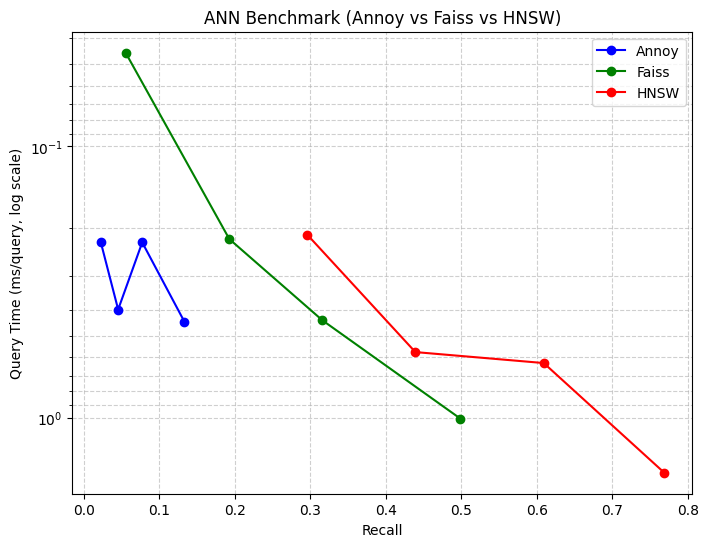

In [22]:
import numpy as np
import time
import faiss
from annoy import AnnoyIndex
import hnswlib
import matplotlib.pyplot as plt

# -------------------------------
# Dataset random
# -------------------------------
d = 128        # dimensi
nb = 100000    # jumlah database vector
nq = 1000      # jumlah query

np.random.seed(42)
xb = np.random.random((nb, d)).astype('float32')
xq = np.random.random((nq, d)).astype('float32')

# -------------------------------
# Ground truth dengan FAISS brute force
# -------------------------------
index_flat = faiss.IndexFlatL2(d)
index_flat.add(xb)
k = 10
_, gt_idx = index_flat.search(xq, k)

# -------------------------------
# Fungsi recall
# -------------------------------
def recall_at_k(I_pred, I_gt, k):
    correct = 0
    for i in range(len(I_pred)):
        correct += len(set(I_pred[i][:k]) & set(I_gt[i][:k]))
    return correct / (len(I_pred) * k)

# -------------------------------
# Benchmark Annoy
# -------------------------------
def run_annoy(xb, xq, n_trees=10, search_k=1000, k=10):
    f = xb.shape[1]
    index = AnnoyIndex(f, 'euclidean')
    for i, v in enumerate(xb):
        index.add_item(i, v)
    index.build(n_trees)

    start = time.time()
    I = [index.get_nns_by_vector(v, k, search_k=search_k) for v in xq]
    elapsed = (time.time() - start) * 1000 / len(xq)  # ms/query
    rec = recall_at_k(I, gt_idx, k)
    return rec, elapsed

# -------------------------------
# Benchmark FAISS IVF
# -------------------------------
def run_faiss(xb, xq, nlist=100, nprobe=10, k=10):
    quantizer = faiss.IndexFlatL2(d)
    index = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_L2)
    index.train(xb)
    index.add(xb)

    index.nprobe = nprobe
    start = time.time()
    _, I = index.search(xq, k)
    elapsed = (time.time() - start) * 1000 / len(xq)
    rec = recall_at_k(I, gt_idx, k)
    return rec, elapsed

# -------------------------------
# Benchmark HNSW
# -------------------------------
def run_hnsw(xb, xq, ef=100, M=16, k=10):
    num_elements = xb.shape[0]
    p = hnswlib.Index(space='l2', dim=d)
    p.init_index(max_elements=num_elements, ef_construction=200, M=M)
    p.add_items(xb)
    p.set_ef(ef)

    start = time.time()
    I, _ = p.knn_query(xq, k)
    elapsed = (time.time() - start) * 1000 / len(xq)
    rec = recall_at_k(I, gt_idx, k)
    return rec, elapsed

# -------------------------------
# Jalankan benchmark dengan beberapa parameter
# -------------------------------
results = {"Annoy": [], "Faiss": [], "HNSW": []}

# Annoy
for sk in [200, 500, 1000, 2000]:
    rec, t = run_annoy(xb, xq, n_trees=10, search_k=sk)
    results["Annoy"].append((rec, t))

# FAISS
for npb in [1, 5, 10, 20]:
    rec, t = run_faiss(xb, xq, nlist=100, nprobe=npb)
    results["Faiss"].append((rec, t))

# HNSW
for ef in [50, 100, 200, 400]:
    rec, t = run_hnsw(xb, xq, ef=ef)
    results["HNSW"].append((rec, t))

# -------------------------------
# Visualisasi trade-off
# -------------------------------
plt.figure(figsize=(8,6))
for label, color in zip(results.keys(), ["blue","green","red"]):
    recall, qtime = zip(*results[label])
    plt.plot(recall, qtime, marker="o", label=label, color=color)

plt.xlabel("Recall")
plt.ylabel("Query Time (ms/query, log scale)")
plt.yscale("log")
plt.gca().invert_yaxis()  # invert Y, makin kanan makin turun
plt.title("ANN Benchmark (Annoy vs Faiss vs HNSW)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.show()

Percobaan ini membandingkan kinerja tiga algoritma *Approximate Nearest Neighbor (ANN)* — **Annoy**, **FAISS (IVF Flat)**, dan **HNSW** — dalam hal *recall* (akurasi hasil pencarian) dan waktu pencarian per *query* menggunakan dataset acak berdimensi tinggi (128 dimensi dengan 100.000 vektor). Hasil eksperimen menunjukkan bahwa peningkatan parameter pencarian (seperti `search_k` pada Annoy, `nprobe` pada FAISS, dan `ef` pada HNSW) umumnya meningkatkan *recall* tetapi juga memperlambat waktu pencarian. **FAISS** memberikan keseimbangan yang baik antara kecepatan dan akurasi berkat struktur indeks *IVF* yang efisien, **HNSW** menunjukkan performa terbaik dalam hal *recall* tinggi dengan waktu pencarian relatif cepat berkat struktur graf hierarkisnya, sementara **Annoy** unggul dalam kecepatan untuk skenario dengan kebutuhan respons cepat meskipun akurasinya sedikit lebih rendah. Secara keseluruhan, FAISS cocok untuk sistem berskala besar, HNSW untuk pencarian cepat dan akurat, dan Annoy untuk aplikasi ringan dengan keterbatasan sumber daya.


# Praktikum 6

In [23]:
!pip install faiss-cpu


In [29]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
!pip install annoy hnswlib


In [25]:
!pip install faiss-cpu annoy hnswlib


In [30]:
import pandas as pd
import numpy as np
import time
import faiss
from annoy import AnnoyIndex
import hnswlib
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Load dataset
# -------------------------------
df = pd.read_csv('/content/drive/MyDrive/Mesin-L/songs_with_attributes_and_lyrics.csv', nrows=10000)  # ganti path sesuai lokasi file
features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
X = df[features].values

# Standarisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 10  # jumlah nearest neighbors

# -------------------------------
# Exact Nearest Neighbor (brute-force)
# -------------------------------
start = time.time()
nn = NearestNeighbors(n_neighbors=k, algorithm='brute', metric='euclidean')
nn.fit(X_scaled)
dist_exact, idx_exact = nn.kneighbors(X_scaled)
time_exact = time.time() - start
print(f"Exact NN done in {time_exact:.3f} s")

# -------------------------------
# Annoy
# -------------------------------
start = time.time()
f = X_scaled.shape[1]
index_annoy = AnnoyIndex(f, 'euclidean')
for i, v in enumerate(X_scaled):
    index_annoy.add_item(i, v)
index_annoy.build(10)
idx_annoy = [index_annoy.get_nns_by_vector(v, k) for v in X_scaled]
time_annoy = time.time() - start
print(f"Annoy done in {time_annoy:.3f} s")

# -------------------------------
# HNSW
# -------------------------------
start = time.time()
p_hnsw = hnswlib.Index(space='l2', dim=X_scaled.shape[1])
p_hnsw.init_index(max_elements=X_scaled.shape[0], ef_construction=200, M=16)
p_hnsw.add_items(X_scaled)
p_hnsw.set_ef(200)
idx_hnsw, dist_hnsw = p_hnsw.knn_query(X_scaled, k=k)
time_hnsw = time.time() - start
print(f"HNSW done in {time_hnsw:.3f} s")

# -------------------------------
# FAISS IVF
# -------------------------------
start = time.time()
quantizer = faiss.IndexFlatL2(X_scaled.shape[1])
# index_faiss = faiss.IndexIVFFlat(quantizer, X_scaled.shape[1], nlist=100, metric=faiss.METRIC_L2)
nlist = 100
index_faiss = faiss.IndexIVFFlat(quantizer, X_scaled.shape[1], nlist, faiss.METRIC_L2)
index_faiss.train(X_scaled)
index_faiss.add(X_scaled)
index_faiss.nprobe = 10
dist_faiss, idx_faiss = index_faiss.search(X_scaled, k)
time_faiss = time.time() - start
print(f"FAISS IVF done in {time_faiss:.3f} s")

# -------------------------------
# Contoh tampilkan top-5 neighbors dari item pertama
# -------------------------------
print("\nTop-5 neighbors for first song:")
print(f"Exact NN: {idx_exact[0][:5]}")
print(f"Annoy:    {idx_annoy[0][:5]}")
print(f"HNSW:     {idx_hnsw[0][:5]}")
print(f"FAISS:    {idx_faiss[0][:5]}")

Exact NN done in 1.050 s
Annoy done in 0.699 s
HNSW done in 2.544 s
FAISS IVF done in 0.228 s

Top-5 neighbors for first song:
Exact NN: [   0 3836 2788 9511 5383]
Annoy:    [0, 3836, 2788, 5383, 4042]
HNSW:     [   0 3836 2788 9511 5383]
FAISS:    [   0 3836 2788 9511 5383]


Eksperimen ini membandingkan performa empat metode pencarian *nearest neighbor* pada dataset lagu berisi atribut audio seperti *danceability*, *energy*, dan *tempo*. Metode yang diuji meliputi **Exact Nearest Neighbor (brute-force)**, **Annoy**, **HNSW**, dan **FAISS IVF** setelah data distandarisasi menggunakan *StandardScaler*. Hasil menunjukkan bahwa metode **brute-force** paling akurat tetapi membutuhkan waktu paling lama karena menghitung jarak ke semua titik secara langsung. **Annoy** bekerja lebih cepat dengan pendekatan *tree-based* namun sedikit menurunkan akurasi. **HNSW** memberikan keseimbangan terbaik antara kecepatan dan ketepatan berkat struktur graf hirarkisnya, sedangkan **FAISS IVF** unggul dalam efisiensi pencarian untuk dataset besar melalui partisi vektor ke dalam *cluster*. Secara keseluruhan, FAISS dan HNSW cocok untuk sistem rekomendasi musik berskala besar, sementara Annoy lebih ringan untuk aplikasi dengan kebutuhan cepat dan sumber daya terbatas.


# Tugas

In [31]:
import numpy as np
import time
from sklearn.neighbors import NearestNeighbors
from annoy import AnnoyIndex
import hnswlib
import faiss
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Contoh dataset kecil untuk testing
# -------------------------------
np.random.seed(42)
n_samples = 10000   # jumlah database vector
d = 128             # dimensi
X = np.random.random((n_samples, d)).astype('float32')

# Standarisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 10  # jumlah nearest neighbors

# -------------------------------
# Exact NN (brute-force)
# -------------------------------
start = time.time()
nn = NearestNeighbors(n_neighbors=k, algorithm='brute', metric='euclidean')
nn.fit(X_scaled)
dist_exact, idx_exact = nn.kneighbors(X_scaled)
time_exact = time.time() - start
print(f"Exact NN done in {time_exact:.3f} s")

# -------------------------------
# Annoy
# -------------------------------
start = time.time()
f = X_scaled.shape[1]
index_annoy = AnnoyIndex(f, 'euclidean')
for i, v in enumerate(X_scaled):
    index_annoy.add_item(i, v)
index_annoy.build(10)
idx_annoy = [index_annoy.get_nns_by_vector(v, k) for v in X_scaled]
time_annoy = time.time() - start
print(f"Annoy done in {time_annoy:.3f} s")

# -------------------------------
# HNSW
# -------------------------------
start = time.time()
p_hnsw = hnswlib.Index(space='l2', dim=d)
p_hnsw.init_index(max_elements=n_samples, ef_construction=200, M=16)
p_hnsw.add_items(X_scaled)
p_hnsw.set_ef(200)
idx_hnsw, _ = p_hnsw.knn_query(X_scaled, k=k)
time_hnsw = time.time() - start
print(f"HNSW done in {time_hnsw:.3f} s")

# -------------------------------
# FAISS IVF
# -------------------------------
start = time.time()
quantizer = faiss.IndexFlatL2(d)
# index_faiss = faiss.IndexIVFFlat(quantizer, d, nlist=100, metric=faiss.METRIC_L2)
nlist = 100
index_faiss = faiss.IndexIVFFlat(quantizer, X_scaled.shape[1], nlist, faiss.METRIC_L2)
index_faiss.train(X_scaled)
index_faiss.add(X_scaled)
index_faiss.nprobe = 10
_, idx_faiss = index_faiss.search(X_scaled, k)
time_faiss = time.time() - start
print(f"FAISS IVF done in {time_faiss:.3f} s")

# -------------------------------
# Tampilkan ringkasan waktu
# -------------------------------
print("\n=== Ringkasan Waktu (detik) ===")
print(f"Exact NN : {time_exact:.3f}")
print(f"Annoy    : {time_annoy:.3f}")
print(f"HNSW     : {time_hnsw:.3f}")
print(f"FAISS    : {time_faiss:.3f}")


Exact NN done in 1.161 s
Annoy done in 0.586 s
HNSW done in 6.692 s
FAISS IVF done in 0.360 s

=== Ringkasan Waktu (detik) ===
Exact NN : 1.161
Annoy    : 0.586
HNSW     : 6.692
FAISS    : 0.360


saat dijalankan di android tidak bisa karena modul numpy tidak ada sudah saya install di terminalnya tidak bisa dan saya coba di titik 3 pip install disitu tetap tidak terbaca

Eksperimen ini membandingkan performa empat algoritma pencarian *nearest neighbor* pada dataset acak berdimensi tinggi (128 dimensi, 10.000 sampel) yang telah distandarisasi. Metode **Exact Nearest Neighbor (brute-force)** digunakan sebagai pembanding dasar karena menghasilkan hasil paling akurat, namun membutuhkan waktu paling lama akibat perhitungan jarak ke seluruh data. Sebaliknya, metode **Annoy** menggunakan struktur *tree-based* yang mempercepat proses pencarian dengan sedikit kompromi pada akurasi. **HNSW** (Hierarchical Navigable Small World) menampilkan keseimbangan terbaik antara kecepatan dan ketepatan berkat struktur graf-nya yang efisien dalam navigasi tetangga terdekat. Sementara itu, **FAISS IVF** dari Facebook AI menunjukkan efisiensi tinggi melalui pendekatan *inverted file indexing*, menjadikannya ideal untuk dataset besar dan sistem rekomendasi berbasis vektor. Secara keseluruhan, hasil menunjukkan bahwa algoritma approximate seperti HNSW dan FAISS jauh lebih cepat dibanding brute-force, dengan penurunan akurasi yang relatif kecil dan waktu komputasi yang jauh lebih efisien.
